# Model

Speedy + Slab Ocean Model

In [1]:
import os
#os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
print("JAX device:", jax.devices())
jax.config.update('jax_disable_jit', False) # Turn off JIT because of an issue in shortwave_radiation.py:169
jax.config.update("jax_debug_infs", True) # doesn't add any time since the saved time is otherwise spent getting the nodal quantities
jax.config.update("jax_debug_nans", False) # some physics fields might be nan

JAX device: [CpuDevice(id=0)]


In [2]:
import sys
from pathlib import Path

paths_check = [
    (Path(os.path.abspath(".")) / ".." / ".." / "jax-gcm").resolve(),
    (Path(os.path.abspath(".")) / "..").resolve(),
]

for module_path in paths_check:
    module_path = str(module_path)
    if module_path in sys.path:
        print("Path exist: ", module_path)
    else:
        print("Add Path: ", module_path)
        sys.path.append(module_path)


Add Path:  /home/t2hsu/projects/jax-gcm
Add Path:  /home/t2hsu/projects/jax-esm


In [3]:
import numpy as np
import xarray as xr
import pandas as pd

from collections import namedtuple

import jcm
#from jcm.model import Model, get_coords
#from jcm.boundaries import initialize_boundaries

from jax_esm.Coupler import Coupler
from jax_esm.components.base import ComponentConfig
from jax_esm.components.Speedy import Speedy
from jax_esm.components.SlabOceanModel import SlabOceanModel
#from jax_esm.components.SlabAtmosphereModel import SlabAtmosphereModel
from jax_esm.components.FluxModel import FluxModel

Path exist:  /home/t2hsu/projects/jax-gcm
Path exist:  /home/t2hsu/projects/jax-esm


## Create Model

In [4]:
total_simulation_time =  20 * 86400.0 # sec
coupler_time_step      =  86400.0  # sec
coupler_steps = int(total_simulation_time / coupler_time_step)

atm_substeps          =  24           # count
atm_save_interval     =  coupler_time_step / atm_substeps # coupler_time_step # sec

ocn_substeps          =  1            # count
ocn_save_interval     = 24 *  3600.0  # sec

flx_substeps          =  1            # count
flx_save_interval     = 24 *  3600.0  # sec

In [5]:
# Coupler Config
config_master = dict(
    total_simulation_time = total_simulation_time,
    time_step = coupler_time_step,
)

# Atmosphere model
config_atm = ComponentConfig(
    name = "atm",
    timestep = coupler_time_step,
    substeps = atm_substeps,
    save_interval = atm_save_interval,
    grid = None,
    params = None,
)

model_atm = Speedy(
    config = config_atm,
)

# Ocean model
config_ocn = ComponentConfig(
    name = "ocn",
    timestep = coupler_time_step,
    substeps = ocn_substeps,
    save_interval = ocn_save_interval,
    grid = None,
    params = dict(
        coords = model_atm.model.coords,
        geometry = model_atm.model.geometry,
        relaxation_time = 86400.0 * 60,
    ),
)
model_ocn = SlabOceanModel(config_ocn)

# Flux model
config_flx = ComponentConfig(
    name = "flx",
    timestep = coupler_time_step,
    substeps = flx_substeps,
    save_interval = flx_save_interval,
    grid = None,
    params = dict(
        coords = model_atm.model.coords,
        geometry = model_atm.model.geometry,
    ),
)
model_flx = FluxModel(config_flx)

In [6]:
coupler = Coupler(
    config = config_master,
    components = dict(
        flx = model_flx,
        atm = model_atm,
        ocn = model_ocn,
    ), 
)

# Plot initial conditions

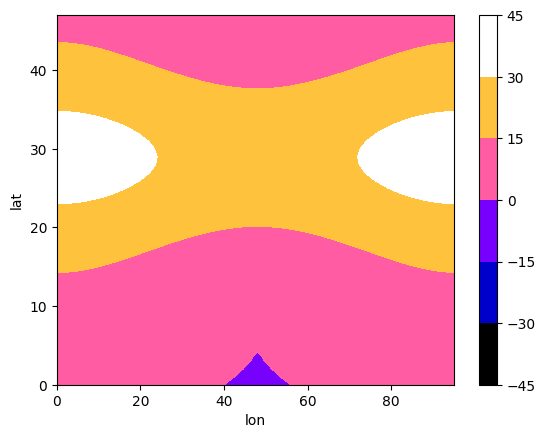

In [7]:
import xarray as xr

init_SST = xr.DataArray(
    data = model_ocn.state_diag.state.T,
    dims = ["lon", "lat"],
)

(init_SST-273.15).plot.contourf(x='lon', y='lat', cmap="gnuplot2", add_colorbar=True)


# Run the Model

In [8]:
import numpy as np


coupler.run(
    total_steps = coupler_steps,
    begin_time = jcm.date.Timestamp.from_datetime64(np.datetime64("2001-01-01")),
    timestep = jcm.date.Timedelta.from_timedelta64(np.timedelta64(int(coupler_time_step), 's')),
)

Coupler Step: 1/20. DateTime = 2001-01-01 00:00:00Save couple state. atm physics keys =  ['shortwave_rad', 'longwave_rad', 'convection', 'mod_radcon', 'humidity', 'condensation', 'surface_flux', 'date', 'land_model']
Execution time: 13.2 seconds.
Coupler Step: 2/20. DateTime = 2001-01-02 00:00:00Save couple state. atm physics keys =  ['shortwave_rad', 'longwave_rad', 'convection', 'mod_radcon', 'humidity', 'condensation', 'surface_flux', 'date', 'land_model']
Execution time: 12.8 seconds.
Coupler Step: 3/20. DateTime = 2001-01-03 00:00:00Save couple state. atm physics keys =  ['shortwave_rad', 'longwave_rad', 'convection', 'mod_radcon', 'humidity', 'condensation', 'surface_flux', 'date', 'land_model']
Execution time: 13.0 seconds.
Coupler Step: 4/20. DateTime = 2001-01-04 00:00:00Save couple state. atm physics keys =  ['shortwave_rad', 'longwave_rad', 'convection', 'mod_radcon', 'humidity', 'condensation', 'surface_flux', 'date', 'land_model']
Execution time: 13.3 seconds.
Coupler Step

In [9]:
import jax.numpy as jnp
def stack_objects(objs):
    # objs is a list of pytrees with same structure
    leaves = jax.tree_util.tree_map(lambda *xs: jnp.stack(xs), *objs)
    return leaves

#stacked_flx = stack_objects(model_flx.trajectory)
#stacked_ocn = stack_objects(model_ocn.trajectory)


In [10]:
print(dir(model_ocn.trajectory))

['__add__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__delitem__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__imul__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__mul__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__rmul__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', 'append', 'clear', 'copy', 'count', 'extend', 'index', 'insert', 'pop', 'remove', 'reverse', 'sort']


In [11]:
import matplotlib.pyplot as plt

## Ocean Model Diagnostics

In [12]:
ocn_traj_ds = model_ocn.convertTrajectoryToXarray()

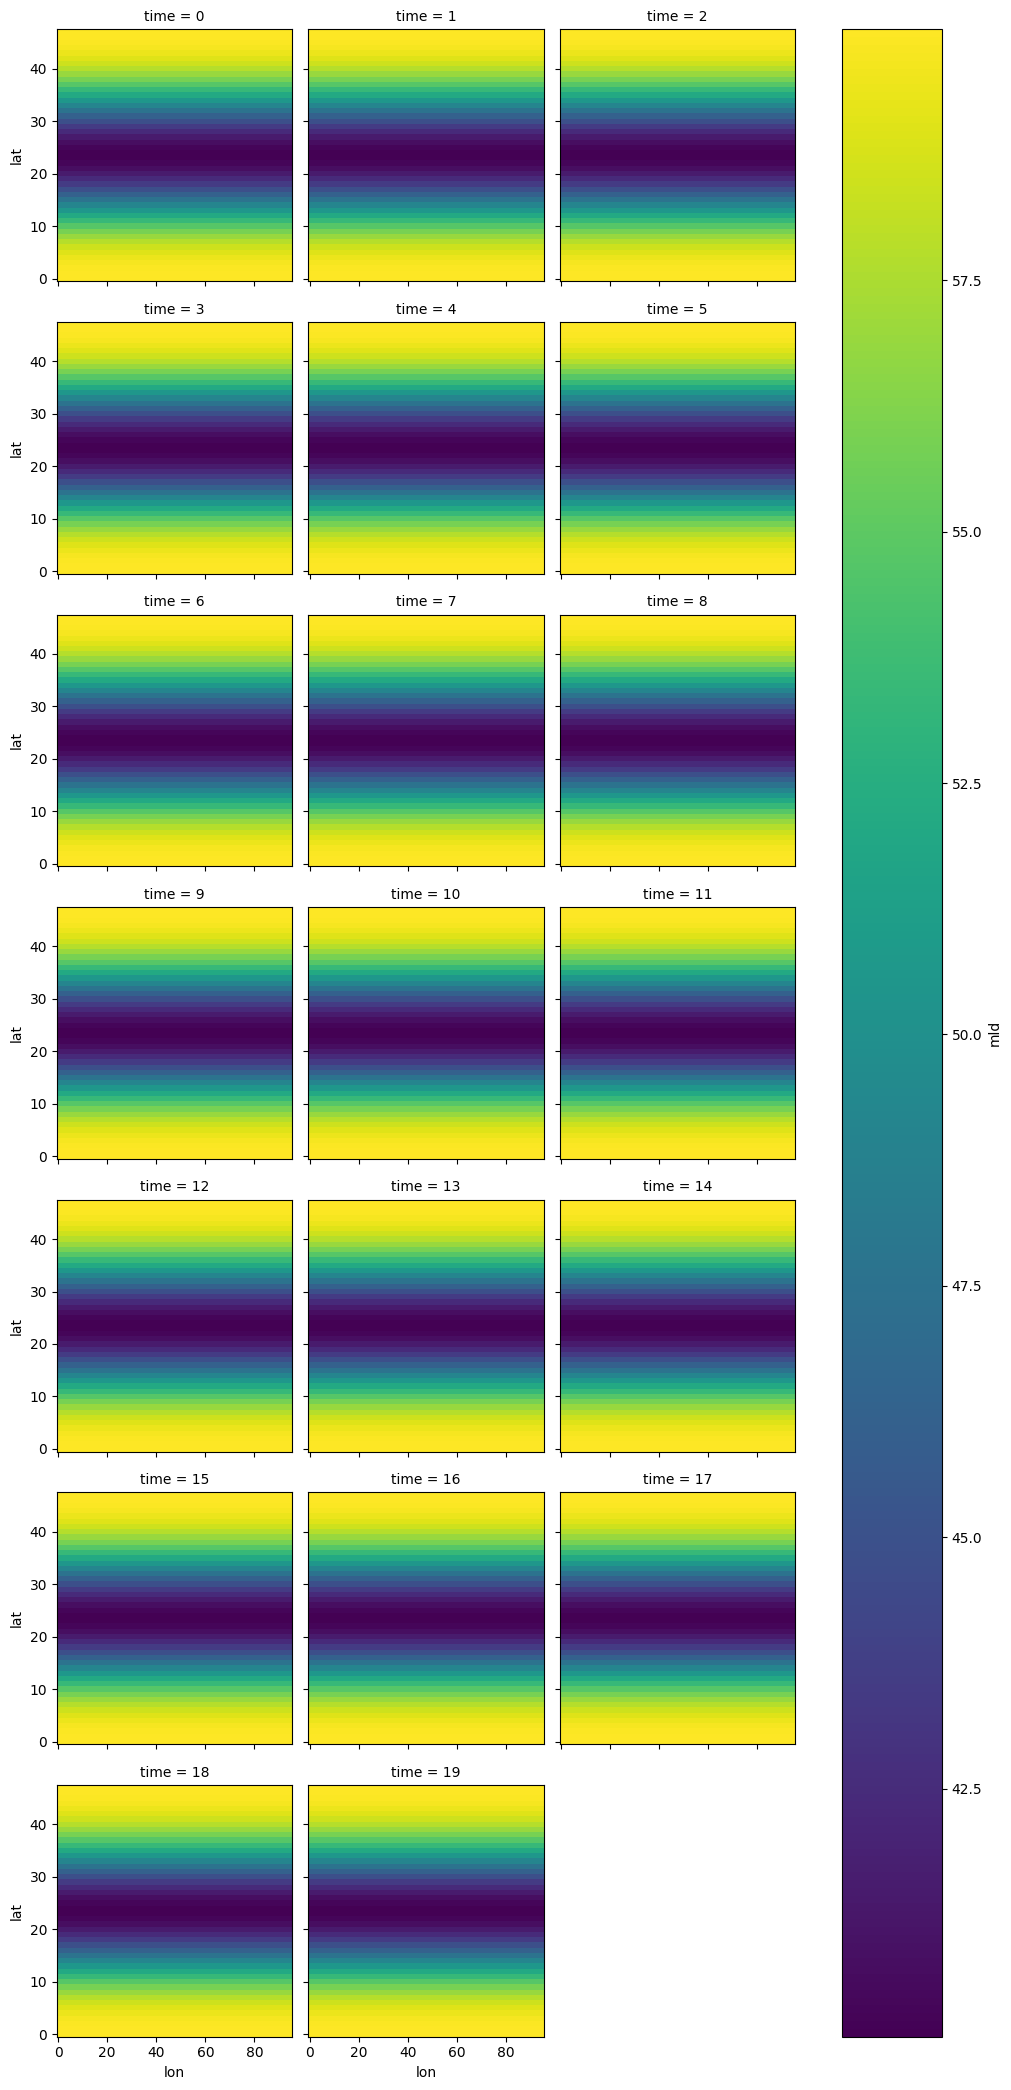

In [13]:
ocn_traj_ds["mld"].plot(x='lon', y='lat', col="time", col_wrap=3)

Text(0.5, 0.98, 'SST')

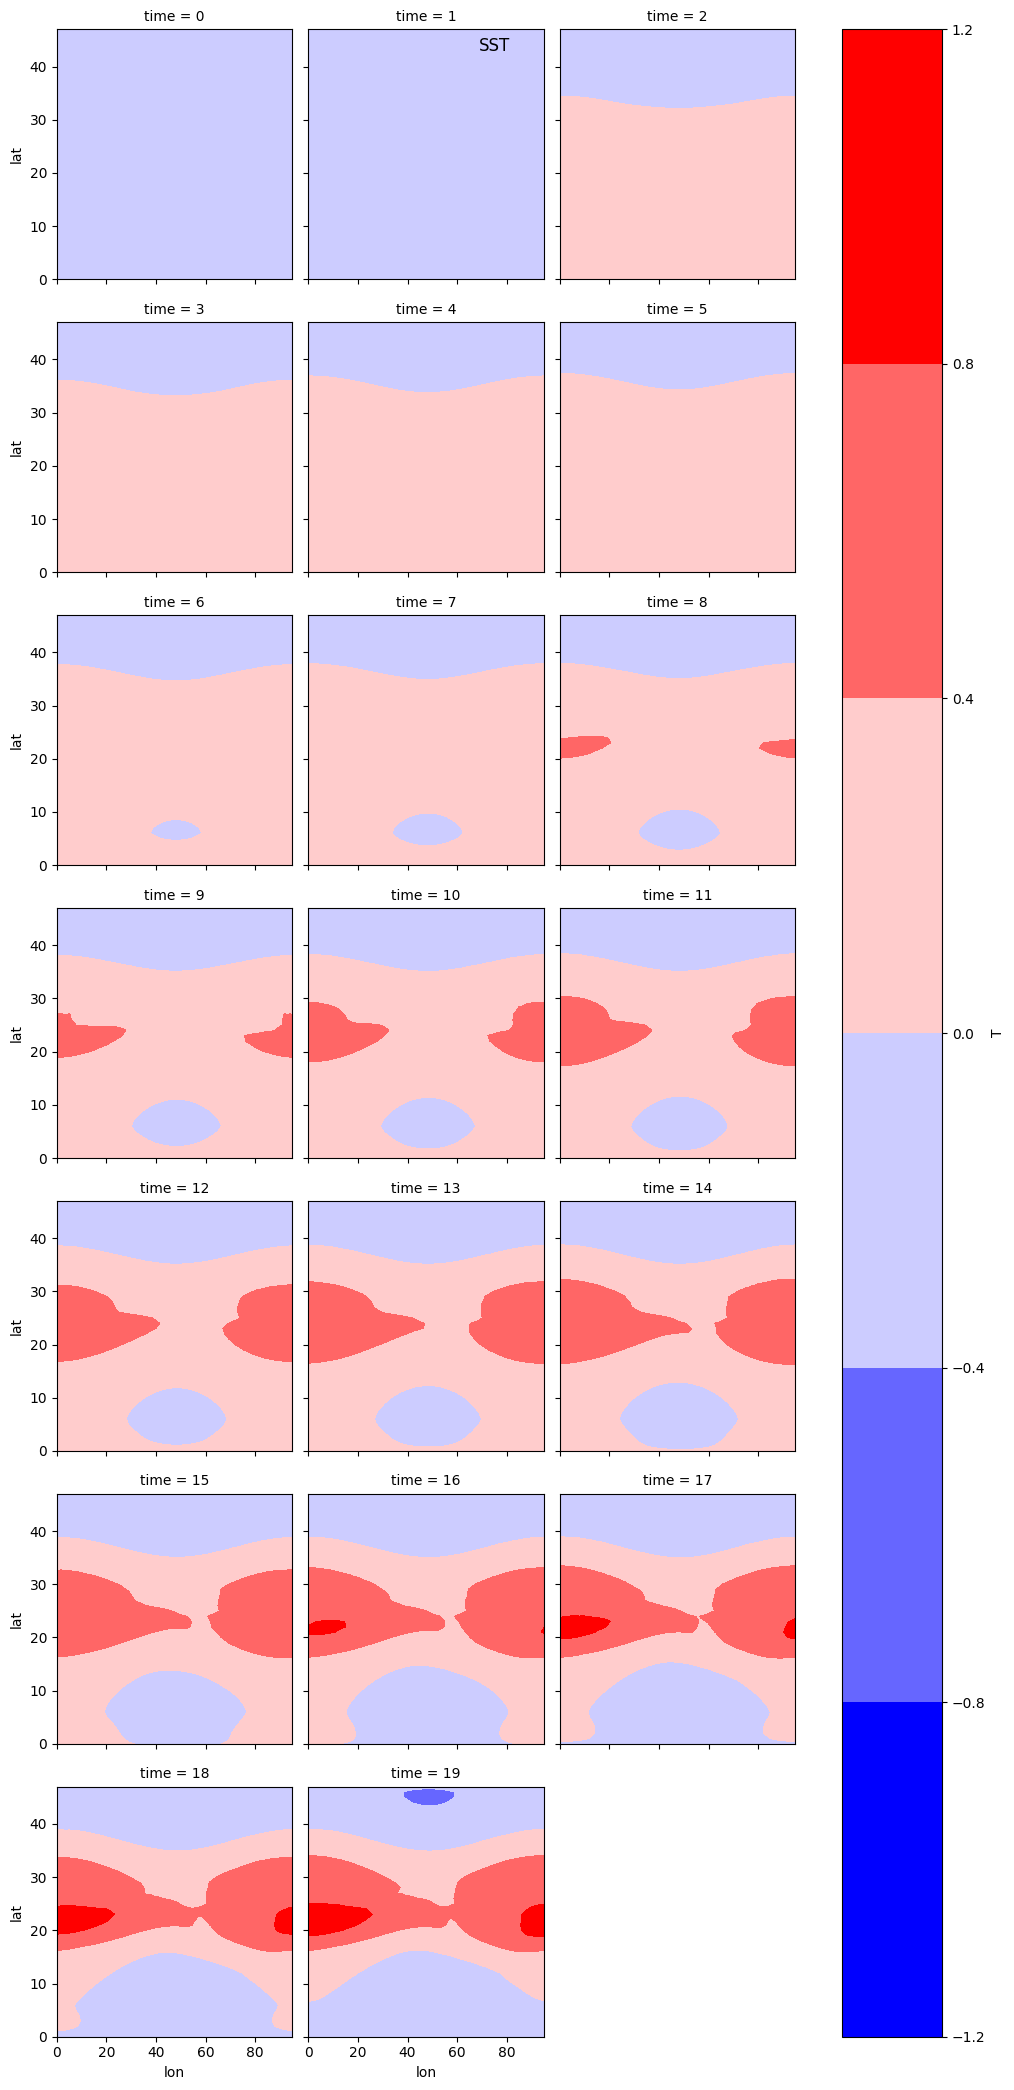

In [14]:
ax = (ocn_traj_ds["T"]-ocn_traj_ds["T"].isel(time=0)).plot.contourf(x='lon', y='lat', col="time", col_wrap=3, cmap="bwr")
plt.suptitle("SST")

## Flux Diagnostics

In [15]:
flx_traj_ds = model_flx.convertTrajectoryToXarray()
#print(model_flx.trajectory[0])


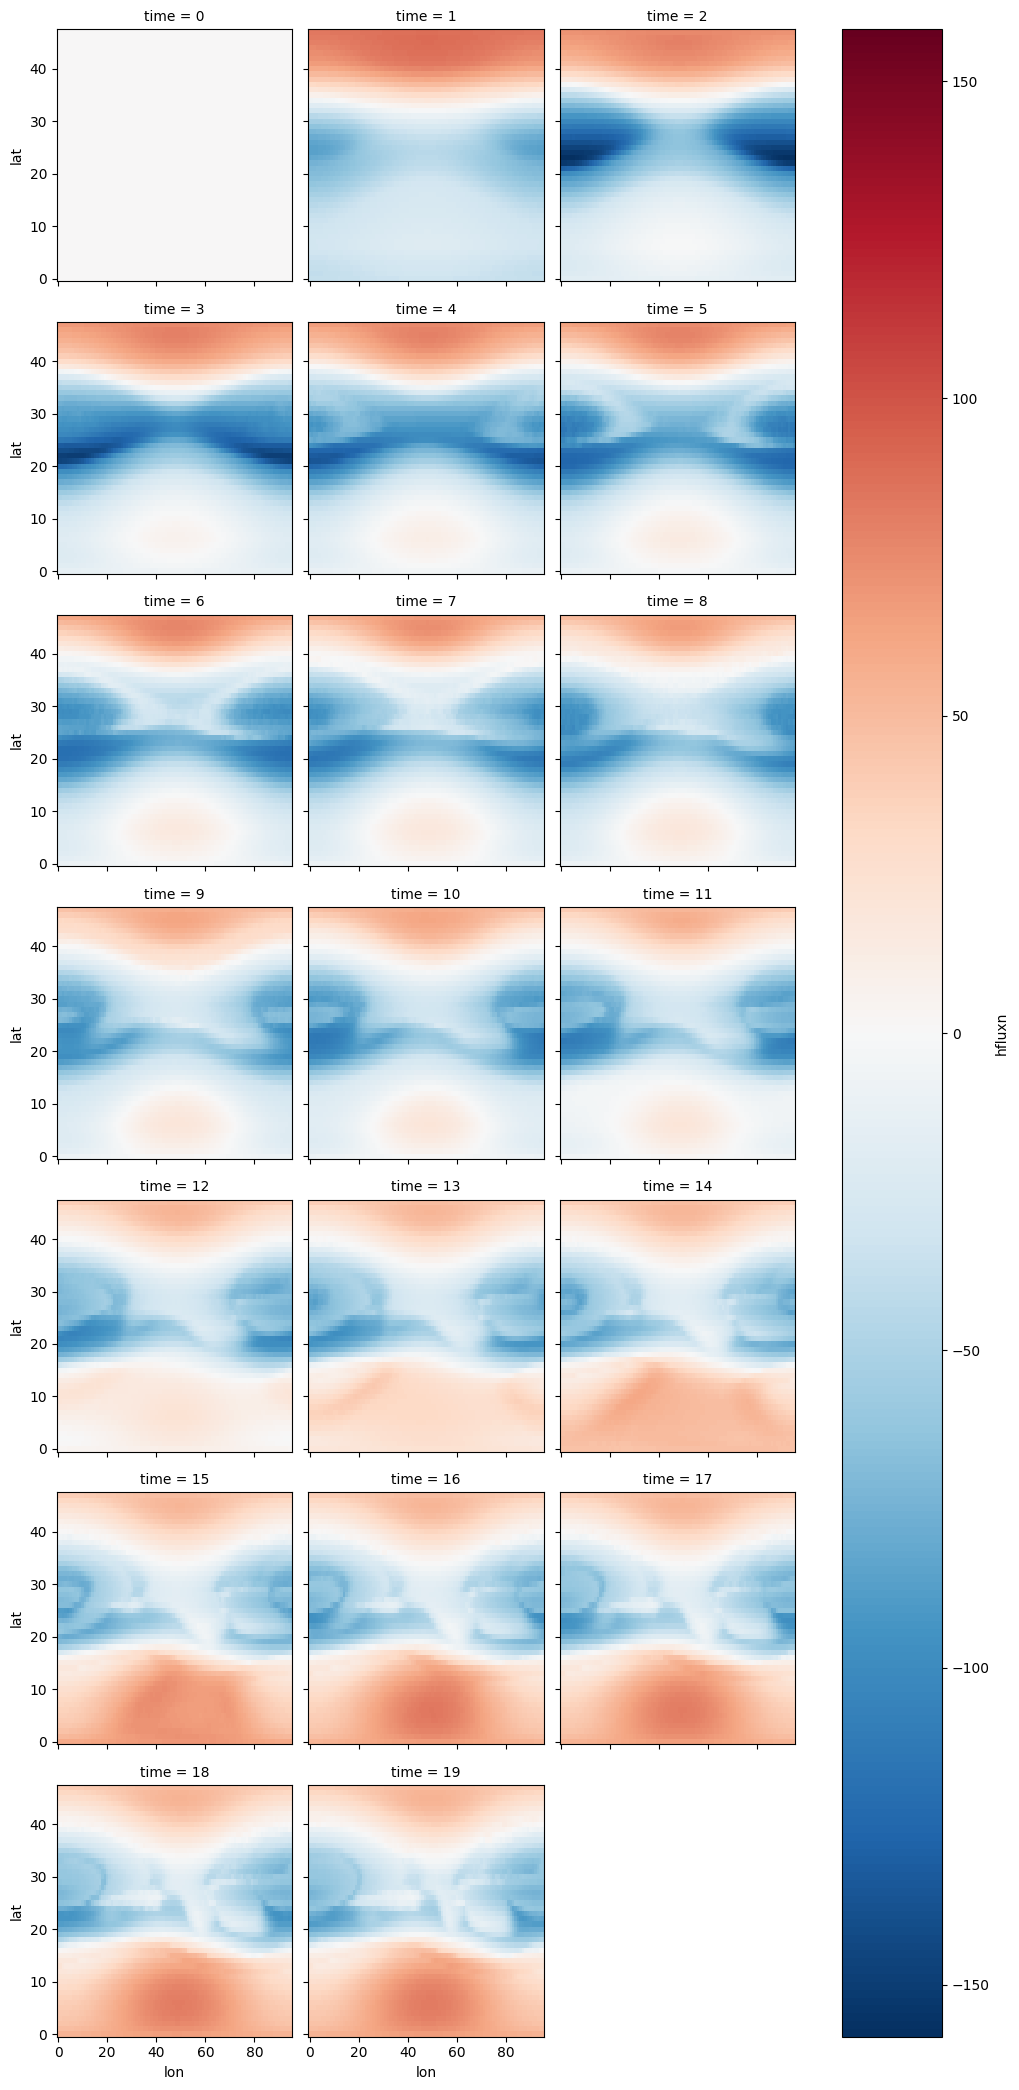

In [16]:
flx_traj_ds["hfluxn"].isel(layer=0).plot(x='lon', y='lat', col="time", col_wrap=3)

## Verify What Atmosphere Model Sees

In [17]:
import numpy as np
import jax
from jcm.model import Predictions
import xarray as xr

time_slice = slice(0, None, atm_substeps)

atm_model = coupler.components["atm"]

pred_ds = []
for i, traj in enumerate(atm_model.trajectory):

    print(f"Doing {i:d}")
    _pred = Predictions(
        dynamics = traj.dynamics,
        physics = traj.physics,
        times = traj.times,
    )

    print("id(traj.physics) = ", hex(id(traj.physics)))

    item_keys = [
        k for k, _ in traj.physics.__dict__.items()
    ]
    print("item keys: ", item_keys)
    pred_ds.append(atm_model.model.predictions_to_xarray(_pred))


pred_ds = xr.combine_nested(pred_ds, "time")

Doing 0
id(traj.physics) =  0x7fe54015a530
item keys:  ['shortwave_rad', 'longwave_rad', 'convection', 'mod_radcon', 'humidity', 'condensation', 'surface_flux', 'date', 'land_model']
Doing 1
id(traj.physics) =  0x7fe5a0127a70
item keys:  ['shortwave_rad', 'longwave_rad', 'convection', 'mod_radcon', 'humidity', 'condensation', 'surface_flux', 'date', 'land_model']
Doing 2
id(traj.physics) =  0x7fe5a01e11d0
item keys:  ['shortwave_rad', 'longwave_rad', 'convection', 'mod_radcon', 'humidity', 'condensation', 'surface_flux', 'date', 'land_model']
Doing 3
id(traj.physics) =  0x7fe5601d6ad0
item keys:  ['shortwave_rad', 'longwave_rad', 'convection', 'mod_radcon', 'humidity', 'condensation', 'surface_flux', 'date', 'land_model']
Doing 4
id(traj.physics) =  0x7fe5203c8eb0
item keys:  ['shortwave_rad', 'longwave_rad', 'convection', 'mod_radcon', 'humidity', 'condensation', 'surface_flux', 'date', 'land_model']
Doing 5
id(traj.physics) =  0x7fe58019b250
item keys:  ['shortwave_rad', 'longwave_ra

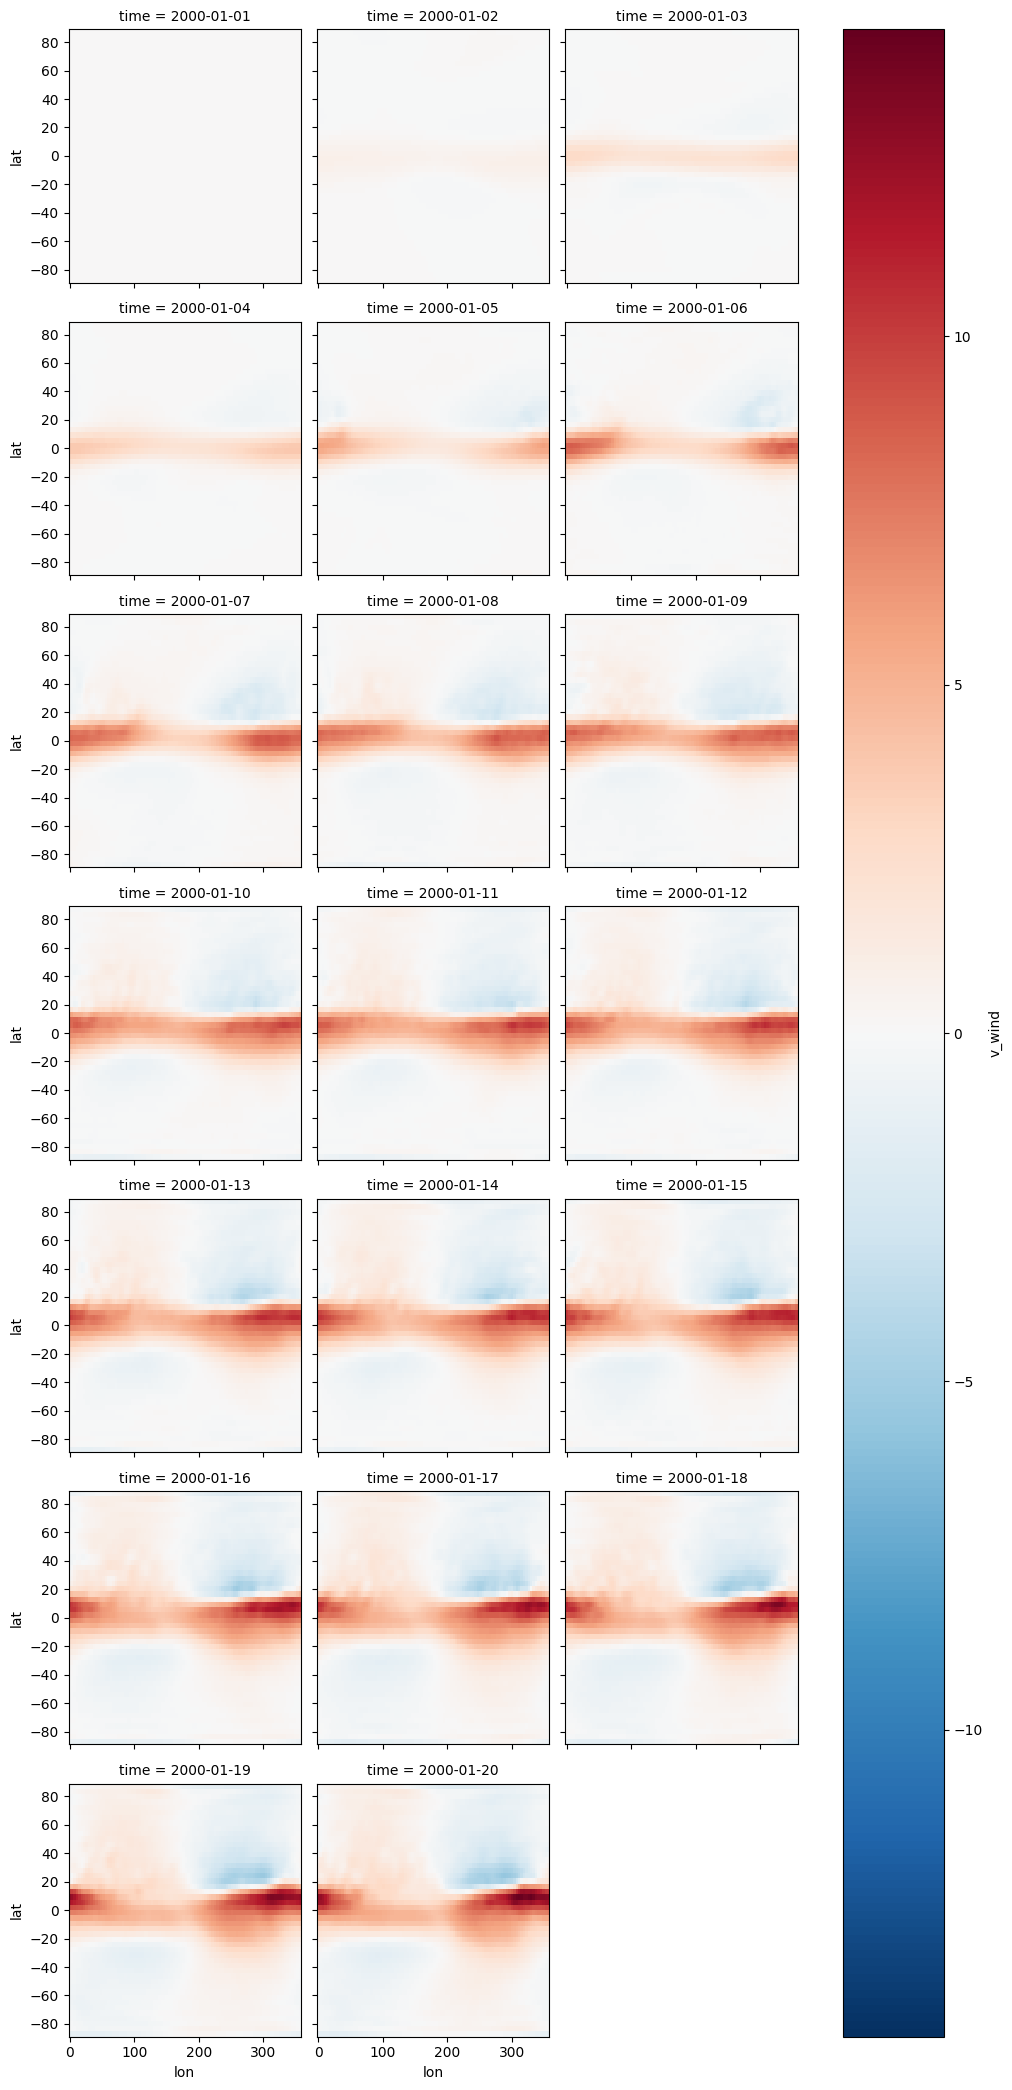

In [18]:
pred_ds["v_wind"].isel(level=0, time=time_slice).plot(x='lon', y='lat', col="time", col_wrap=3)

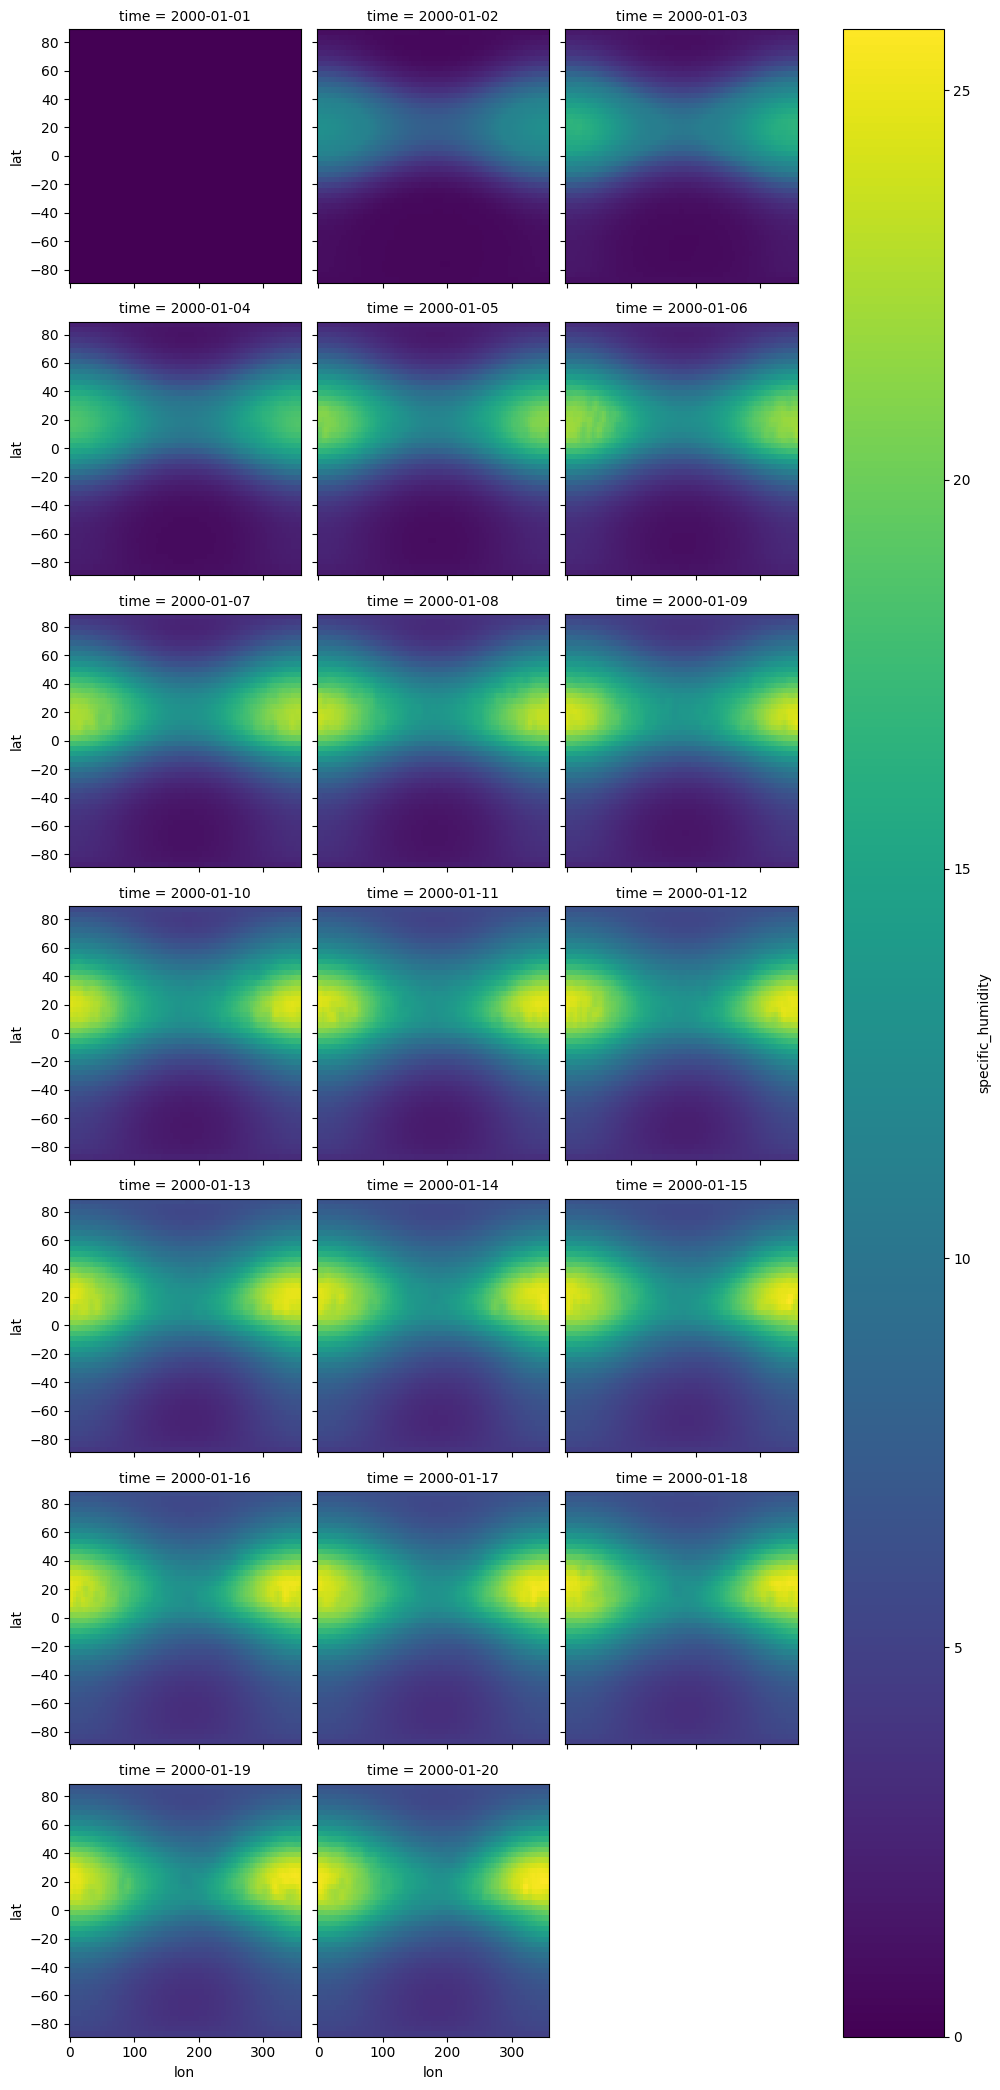

In [19]:
pred_ds["specific_humidity"].isel(level=0, time=time_slice).plot(x='lon', y='lat', col="time", col_wrap=3)

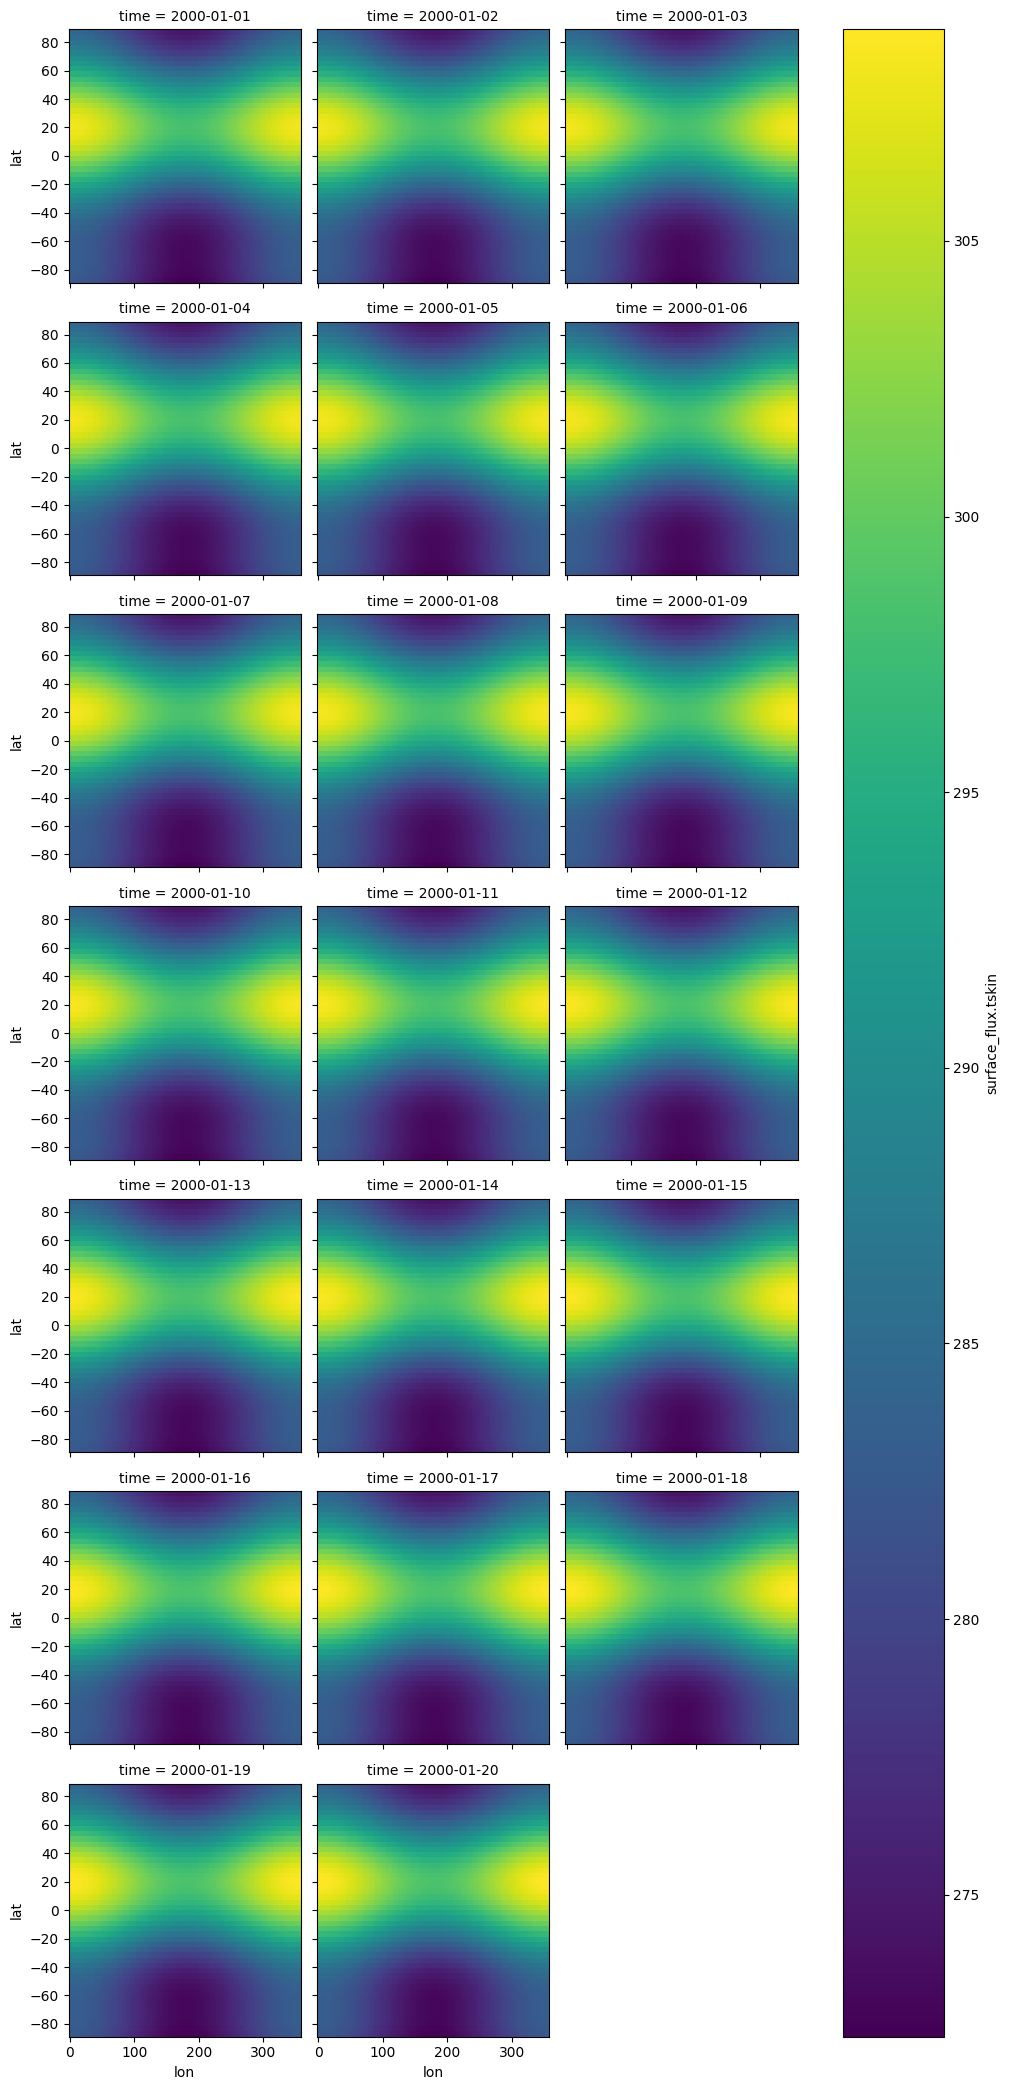

In [20]:
pred_ds["surface_flux.tskin"].isel(time=time_slice).plot(x='lon', y='lat', col="time", col_wrap=3)

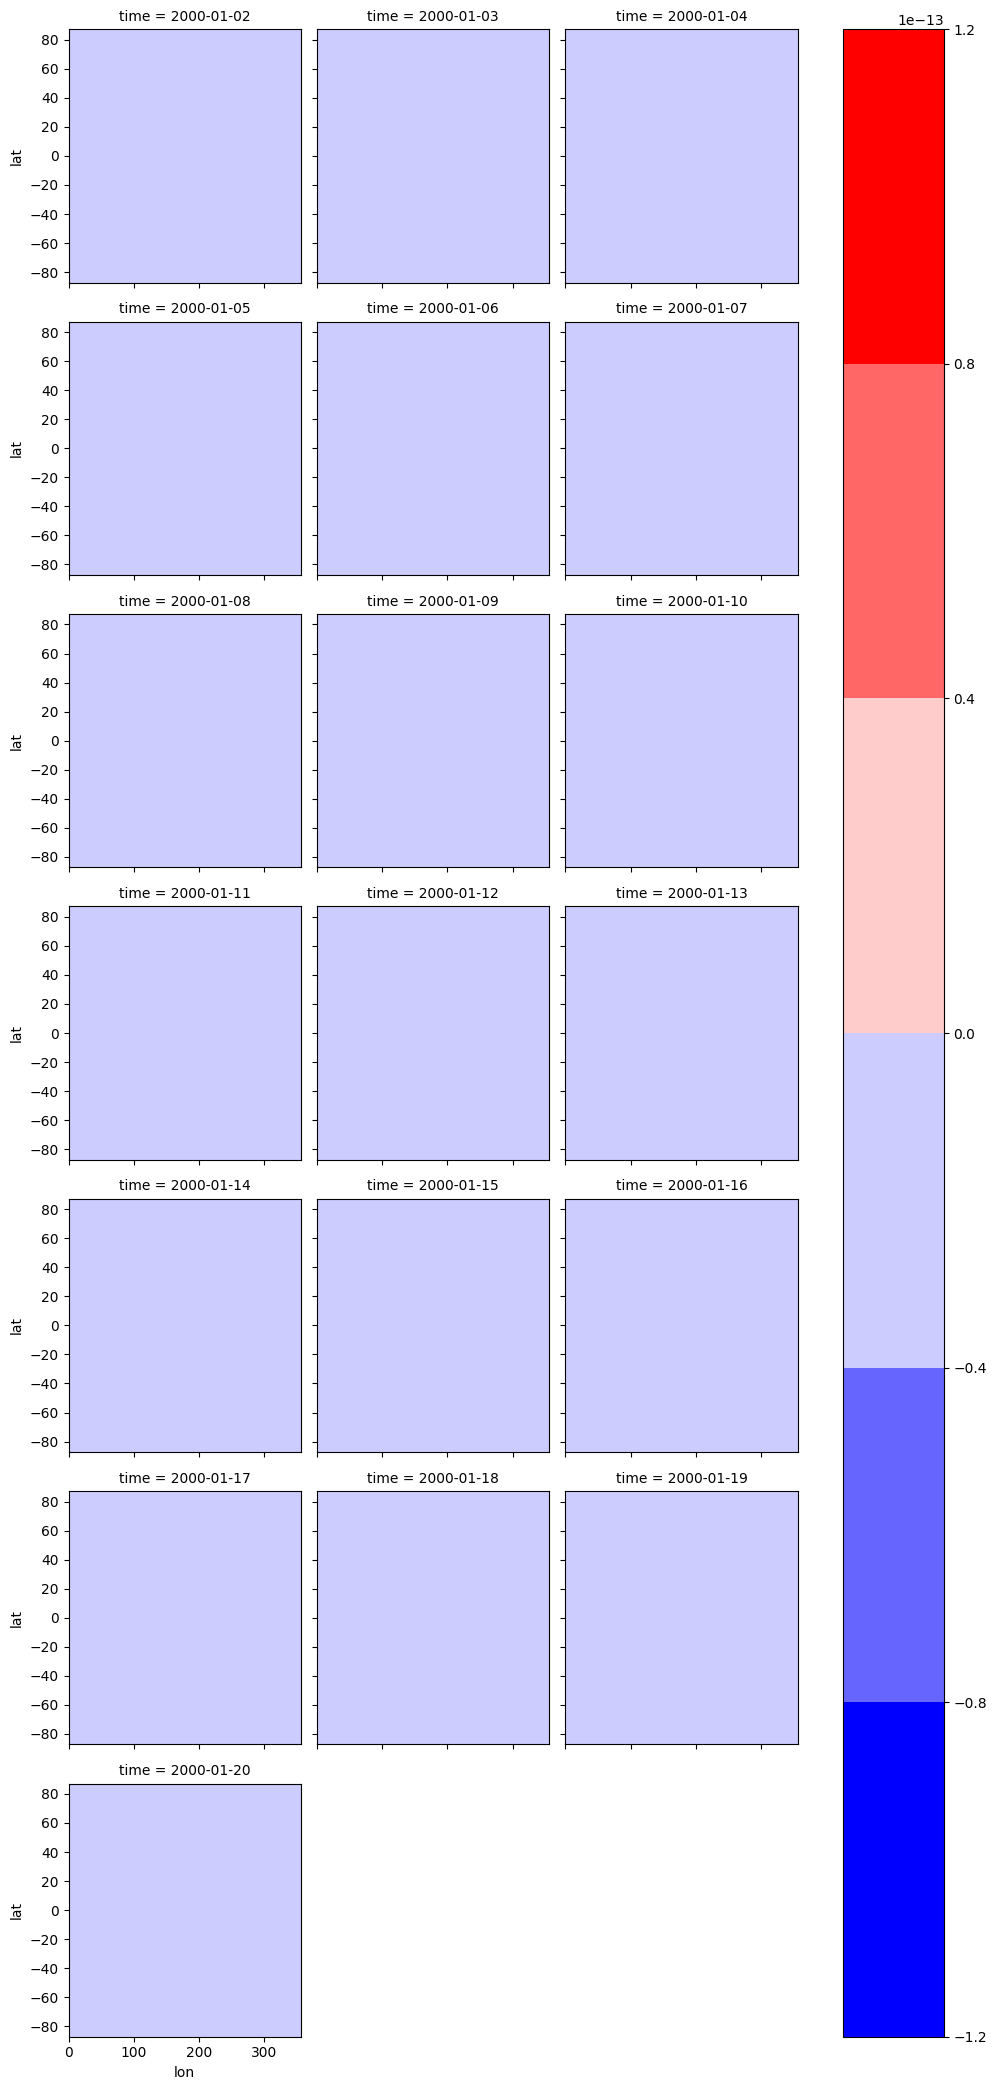

In [21]:
daily_sst_atm = pred_ds["surface_flux.tskin"].isel(time=time_slice).isel(time=slice(1, None, None))
daily_sst_ocn = ocn_traj_ds["T"].isel(time=slice(0, -1, None))

SST_diff = daily_sst_atm - daily_sst_ocn 
SST_diff.plot.contourf(x='lon', y='lat', col="time", col_wrap=3, cmap="bwr")

In [22]:
"""
import time

start_time = time.time()


init_cplstate = coupler.state.copy()
cplstate = init_cplstate.copy()

cpl_forward_func = None
for step in range(coupler_steps):

    _start_time = time.time()
    print(f"Coupler Step: {step+1:d}/{coupler_steps:d}. ", end="")
    cpl_forward_func = coupler.genForwardFunc(first_time=step==0)
    cplstate = cpl_forward_func(cplstate)
    coupler.record(cplstate)
    _end_time = time.time()
    _elapsed_time = _end_time - _start_time
    print(f"Execution time: {_elapsed_time:.1f} seconds.")

#record(recorder, step, cplstate, record_names)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed Time: {elapsed_time:.1f} seconds.")
"""

'\nimport time\n\nstart_time = time.time()\n\n\ninit_cplstate = coupler.state.copy()\ncplstate = init_cplstate.copy()\n\ncpl_forward_func = None\nfor step in range(coupler_steps):\n\n    _start_time = time.time()\n    print(f"Coupler Step: {step+1:d}/{coupler_steps:d}. ", end="")\n    cpl_forward_func = coupler.genForwardFunc(first_time=step==0)\n    cplstate = cpl_forward_func(cplstate)\n    coupler.record(cplstate)\n    _end_time = time.time()\n    _elapsed_time = _end_time - _start_time\n    print(f"Execution time: {_elapsed_time:.1f} seconds.")\n\n#record(recorder, step, cplstate, record_names)\n\nend_time = time.time()\nelapsed_time = end_time - start_time\nprint(f"Elapsed Time: {elapsed_time:.1f} seconds.")\n'